Data file: d:\eBATS\data\C0003\C0003R03_PARK25_LC_1D_SCAN.xlsx
Number of scan cases: 100


,case_id,W_channel_mm,H_channel_mm,L_channel_mm,num_parallel_channels,m_dot_channel_kg_s,Dh_mm,u_water_m_s,Re_water,P_pump,...,DeltaT_mission_max_C,Twater_out_cruise_end_C,dTmax_takeoff_C,dTmax_climb_C,dTmax_transition1_C,dTmax_cruise_C,dTmax_transition2_C,dTmax_descent_C,dTmax_hover_C,dTmax_landing_C
0,1,6.0,2,380,32,0.001406,3.0,0.117535,395.004064,0.019473,...,2.994696,25.459873,0.411598,1.391496,0.431458,-1.101141,-0.609492,0.534724,10.052057,0.238246
1,2,6.0,2,390,32,0.001406,3.0,0.117535,395.004064,0.019985,...,3.059817,25.459682,0.411532,1.389766,0.415699,-1.101666,-0.606477,0.535329,9.996364,0.235105
2,3,6.0,2,400,32,0.001406,3.0,0.117535,395.004064,0.020498,...,3.123681,25.459503,0.411469,1.388122,0.400407,-1.101823,-0.603575,0.535924,9.942467,0.232060
3,4,6.0,2,410,32,0.001406,3.0,0.117535,395.004064,0.021010,...,3.186290,25.459334,0.411412,1.386561,0.385555,-1.101654,-0.600780,0.536511,9.890279,0.229107
4,5,6.0,2,420,32,0.001406,3.0,0.117535,395.004064,0.021523,...,3.247648,25.459175,0.411357,1.385080,0.371120,-1.101194,-0.598086,0.537090,9.839714,0.226241


Tmax range: 35.1309 - 37.7001 °C
20 rows for L_channel_mm = 380 mm
20 rows for L_channel_mm = 400 mm
20 rows for L_channel_mm = 420 mm
Figure saved to: d:\eBATS\out\C0003\C0003R03_PARK25_LC_1D_SCAN_Tmax_dT_E_stage2.png


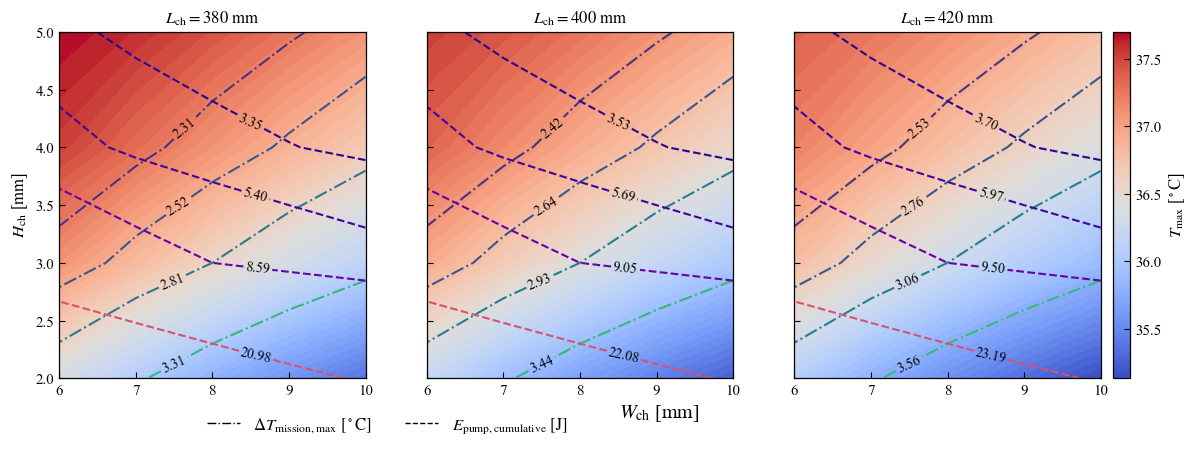

In [3]:
# plot the thermal performance for the SCAN2 channel-geometry study

from pathlib import Path

import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize
from matplotlib.lines import Line2D


# read SCAN2 data
root_dir = os.path.abspath("../..")
CASE_ID = "C0003"

CASE_NAME = "C0003R03_PARK25_LC_1D_SCAN"

data_file = os.path.join(
    root_dir,
    "data",
    CASE_ID,
    f"{CASE_NAME}.xlsx"
)
sheet_name = "Geometry scan_stage2"

data = pd.read_excel(
    data_file,
    sheet_name=sheet_name
)

print(f"Data file: {data_file}")
print(f"Number of scan cases: {len(data)}")
display(data.head())


# format contour labels
def label_fmt(x):
    return f"{x:.2f}"


# figure style
base_fontsize = 12

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': base_fontsize,
    'axes.labelsize': base_fontsize,
    'axes.titlesize': base_fontsize,
    'xtick.labelsize': base_fontsize * 0.9,
    'ytick.labelsize': base_fontsize * 0.9,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})


# plotting columns
key_L = 'L_channel_mm'
key_x = 'W_channel_mm'
key_y = 'H_channel_mm'
key_val_T = 'Tmax_mission_C'
key_val_dT = 'DeltaT_mission_max_C'
key_val_E = 'E_pump_cumulative'

# L_array = np.sort(
#     data[key_L].unique()
# )

L_array = np.array([380.0, 400.0, 420.0])

# global Tmax range for the shared colorbar
T_min = data[key_val_T].min()
T_max = data[key_val_T].max()

print(
    f"Tmax range: "
    f"{T_min:.4f} - {T_max:.4f} °C"
)

# colormaps
cmap_T = sns.color_palette(
    "coolwarm",
    as_cmap=True
)
cmap_dT = sns.color_palette("viridis", as_cmap=True)
cmap_E = sns.color_palette("plasma", as_cmap=True)


# create one subplot for each channel length
fig, axes = plt.subplots(
    1,
    len(L_array),
    figsize=(16, 4.5),
    sharey=True
)
axes = np.atleast_1d(axes)

for i, L_channel in enumerate(L_array):
    ax = axes[i]

    # select the current channel length
    thermal_data = data[
        np.isclose(
            data[key_L],
            L_channel
        )
    ].copy()

    print(
        f"{len(thermal_data)} rows for "
        f"{key_L} = {L_channel:g} mm"
    )

    # extract the coordinates
    x_values = np.sort(
        thermal_data[key_x].unique()
    )
    y_values = np.sort(
        thermal_data[key_y].unique()
    )

    # transform the scan results into 2D arrays
    Z_values_T = (
        thermal_data
        .pivot(
            index=key_y,
            columns=key_x,
            values=key_val_T
        )
        .reindex(
            index=y_values,
            columns=x_values
        )
        .values
    )

    Z_values_dT = (
        thermal_data
        .pivot(
            index=key_y,
            columns=key_x,
            values=key_val_dT
        )
        .reindex(
            index=y_values,
            columns=x_values
        )
        .values
    )

    Z_values_E = (
        thermal_data
        .pivot(
            index=key_y,
            columns=key_x,
            values=key_val_E
        )
        .reindex(
            index=y_values,
            columns=x_values
        )
        .values
    )

    # local ranges for the contour lines
    dT_min = Z_values_dT.min()
    dT_max = Z_values_dT.max()
    E_min = Z_values_E.min()
    E_max = Z_values_E.max()

    # exactly four contour levels selected by spatial positions in H_ch
    target_y = np.linspace(
        y_values.min() + 0.3,
        y_values.max() - 0.6,
        4
    )

    # use the middle W_ch column as the reference so that the contour
    # lines are distributed more evenly over the plotting area
    mid_col = len(x_values) // 2

    levels_dT = np.interp(
        target_y,
        y_values,
        Z_values_dT[:, mid_col]
    )
    levels_E = np.interp(
        target_y,
        y_values,
        Z_values_E[:, mid_col]
    )

    # contour requires strictly increasing level values
    levels_dT = np.sort(levels_dT)
    levels_E = np.sort(levels_E)

    # Tmax filled contour
    ax.contourf(
        x_values,
        y_values,
        Z_values_T,
        levels=50,
        cmap=cmap_T,
        vmin=T_min,
        vmax=T_max
    )

    # temperature-difference contour lines
    cs_dT = ax.contour(
        x_values,
        y_values,
        Z_values_dT,
        levels=levels_dT,
        cmap=cmap_dT,
        vmin=dT_min,
        vmax=dT_max,
        linestyles='dashdot'
    )

    # pump-energy contour lines
    cs_E = ax.contour(
        x_values,
        y_values,
        Z_values_E,
        levels=levels_E,
        cmap=cmap_E,
        vmin=E_min,
        vmax=E_max,
        linestyles='dashed'
    )

    # separate the two groups of contour labels horizontally to avoid overlap
    x_left = x_values[0] + 0.35 * (x_values[-1] - x_values[0])
    x_right = x_values[0] + 0.65 * (x_values[-1] - x_values[0])

    manual_dT = [(x_left, y) for y in target_y]
    manual_E = [(x_right, y) for y in target_y]

    ax.clabel(
        cs_dT,
        inline=True,
        fontsize=10,
        fmt=label_fmt,
        colors='black',
        manual=manual_dT
    )
    ax.clabel(
        cs_E,
        inline=True,
        fontsize=10,
        fmt=label_fmt,
        colors='black',
        manual=manual_E
    )

    ax.set_title(
        rf"$L_\mathrm{{ch}}={L_channel:g}$ mm"
    )
    # ax.set_xlabel(
    #     r"$W_\mathrm{ch}$ [mm]"
    # )

    if i == 0:
        ax.set_ylabel(
            r"$H_\mathrm{ch}$ [mm]"
        )


fig.supxlabel(r"$W_\mathrm{ch}$ [mm]")

# add a legend for the contour-line types
legend_elements = [
    Line2D(
        [0],
        [0],
        color='black',
        lw=1,
        linestyle='dashdot',
        label=(
            r'$\Delta T_\mathrm{mission,max}'
            r'~[\mathrm{^\circ C}]$'
        )
    ),
    Line2D(
        [0],
        [0],
        color='black',
        lw=1,
        linestyle='dashed',
        label=(
            r'$E_\mathrm{pump,cumulative}'
            r'~[\mathrm{J}]$'
        )
    ),
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=2,
    fontsize=base_fontsize,
    frameon=False,
    bbox_to_anchor=(
        0.33,
        -0.05
    )
)


# add the shared Tmax colorbar
sm = plt.cm.ScalarMappable(
    cmap=cmap_T,
    norm=Normalize(
        vmin=T_min,
        vmax=T_max
    )
)
sm.set_array([])

fig.colorbar(
    sm,
    ax=axes.tolist(),
    label=r'$T_{\max}$ [$^\circ$C]',
    pad=0.01
)


# save the figure
output_folder = os.path.join(
    root_dir,
    'out',
    CASE_ID
)
os.makedirs(
    output_folder,
    exist_ok=True
)

file_name = f"{CASE_NAME}_Tmax_dT_E_stage2.png"

output_file = os.path.join(
    output_folder,
    file_name
)

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches='tight'
)

print(
    'Figure saved to:',
    output_file
)

plt.show()

# save the figure to a specified output folder (for paper drafting)

output_folder = r"D:\Workspace\Paper_eBATS\images" # the working directory of the paper draft

import os
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    
# overwrite the file
fig.savefig(os.path.join(output_folder, file_name), dpi=300, bbox_inches='tight')
